## 1. Problem Definition

### Dataset
The dataset used in this project contains **4,788 Premier League matches** 
from the **2019–2024 seasons**, with 28 features per match including 
team statistics, match context, and performance metrics.

**Source:** [Premier League Matches Dataset — Kaggle](https://www.kaggle.com/datasets/ajaxianazarenka/premier-league)

---

### Regression Problem

**What are we predicting?**  
The number of goals scored by a team in a match.

**Target variable:** `gf` (goals for)  
**Unit of measurement:** goals (integer values)  
**Value range:** 0 to 9 goals per match  
**Typical range:** 0 to 3 goals (covers ~85% of matches)

**Input features:** venue (home/away), xG, possession, shots, 
shots on target, opponent, formation, season.

**Practical relevance:**  
Goal prediction is used in match previews, fantasy football platforms, 
and tactical analysis. Knowing how many goals a team is likely to score 
helps quantify attacking threat and supports pre-match decision making.

**Why this problem?**  
Goals are the most direct measure of attacking performance in football. 
Predicting goal counts is a natural regression task with a clear, 
interpretable output variable and strong feature candidates such as 
expected goals (xG) and shots on target.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visual settings
sns.set_theme(style="whitegrid") # Set Seaborn theme for better aesthetics
plt.rcParams['figure.figsize'] = (10, 5) # Set default figure size for plots

df = pd.read_csv('../datasets/premier-league-matches.csv')
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset shape: 4788 rows, 28 columns


## 2. First Look at the Data

Before any analysis, we inspect the general structure 
of the dataset: columns, data types, and first records.

In [18]:
# First 5 rows
display(df.head())

# Data types
print("\nData types:")
print(df.dtypes)

# General statistics
print("\nDescriptive statistics:")
display(df[['gf','ga','xg','xga','poss','sh','sot']].describe().round(2))

,Unnamed: 0,date,time,comp,round,day,venue,result,gf,ga,...,match report,notes,sh,sot,dist,fk,pk,pkatt,season,team
0,0,2020-09-21,20:15 (21:15),Premier League,Matchweek 2,Mon,Away,W,3,1,...,Match Report,NaN,13,8,21.1,2,1,1,2024,Manchester City
1,2,2020-09-27,16:30 (17:30),Premier League,Matchweek 3,Sun,Home,L,2,5,...,Match Report,NaN,16,5,19.8,1,0,0,2024,Manchester City
2,4,2020-10-03,17:30 (18:30),Premier League,Matchweek 4,Sat,Away,D,1,1,...,Match Report,NaN,23,1,18.2,1,0,0,2024,Manchester City
3,5,2020-10-17,17:30 (18:30),Premier League,Matchweek 5,Sat,Home,W,1,0,...,Match Report,NaN,13,5,17.7,0,0,0,2024,Manchester City
4,7,2020-10-24,12:30 (13:30),Premier League,Matchweek 6,Sat,Away,D,1,1,...,Match Report,NaN,14,7,20.9,1,0,0,2024,Manchester City



Data types:
Unnamed: 0        int64
date                str
time                str
comp                str
round               str
day                 str
venue               str
result              str
gf                int64
ga                int64
opponent            str
xg              float64
xga             float64
poss              int64
attendance      float64
captain             str
formation           str
referee             str
match report        str
notes           float64
sh                int64
sot               int64
dist            float64
fk                int64
pk                int64
pkatt             int64
season            int64
team                str
dtype: object

Descriptive statistics:


,gf,ga,xg,xga,poss,sh,sot
count,4788.00,4788.00,4788.00,4788.00,4788.00,4788.00,4788.00
mean,1.45,1.41,1.40,1.36,50.43,12.62,4.26
std,1.31,1.29,0.83,0.81,12.81,5.55,2.46
min,0.00,0.00,0.00,0.00,18.00,0.00,0.00
25%,0.00,0.00,0.80,0.70,41.00,9.00,2.00
50%,1.00,1.00,1.30,1.20,51.00,12.00,4.00
75%,2.00,2.00,1.90,1.80,60.00,16.00,6.00
max,9.00,9.00,7.00,7.00,82.00,36.00,15.00


### Performance Statistics — Column Descriptions

| Column | Full Name | Description |
|--------|-----------|-------------|
| `gf` | Goals For | Number of goals scored by the team |
| `ga` | Goals Against | Number of goals conceded by the team |
| `xg` | Expected Goals | Statistical estimate of goals expected based on shot quality |
| `xga` | Expected Goals Against | Expected goals conceded based on opponent shot quality |
| `poss` | Possession | Percentage of ball possession |
| `sh` | Shots | Total shots attempted |
| `sot` | Shots on Target | Shots that were directed on target |
| `dist` | Average Shot Distance | Average distance of shots from goal (in yards) |
| `fk` | Free Kicks | Shots taken from free kicks |
| `pk` | Penalty Kicks Scored | Goals scored from the penalty spot |
| `pkatt` | Penalty Kicks Attempted | Total penalty kicks attempted |

### Initial Observations

- The dataset covers **5 seasons** (2019–2024)
- `gf` and `ga` represent goals scored and conceded
- `xg` and `xga` = **expected goals** — a statistical estimate 
  of goals expected based on shot quality
- `poss` = team possession percentage
- `gf` values range between 0 and 9 goals per match

## 3. Data Quality

We check for missing values, duplicates, 
and irrelevant columns.

In [19]:
# Missing values
print("Missing values per column:")
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing)

# Missing percentage
print("\nMissing value percentage:")
print((missing / len(df) * 100).round(2))

# Duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Irrelevant columns
print("\nColumns to drop: 'notes', 'Unnamed: 0', 'match report'")

Missing values per column:
attendance    1633
notes         4788
dist             2
dtype: int64

Missing value percentage:
attendance     34.11
notes         100.00
dist            0.04
dtype: float64

Duplicate rows: 0

Columns to drop: 'notes', 'Unnamed: 0', 'match report'


### Data Quality Conclusions

- **`attendance`** is missing in ~34% of cases — 
  likely matches played without fans (COVID-19, 2020–2021).
  We will either exclude it or impute with the median.
- **`dist`** is missing in only 2 rows — negligible, 
  we will drop those rows.
- **`notes`** is entirely empty — we will drop this column.
- **Zero duplicates** — clean dataset 

## 4. Distribution Analysis

We analyze the distribution of numerical and 
categorical variables to understand the data structure.

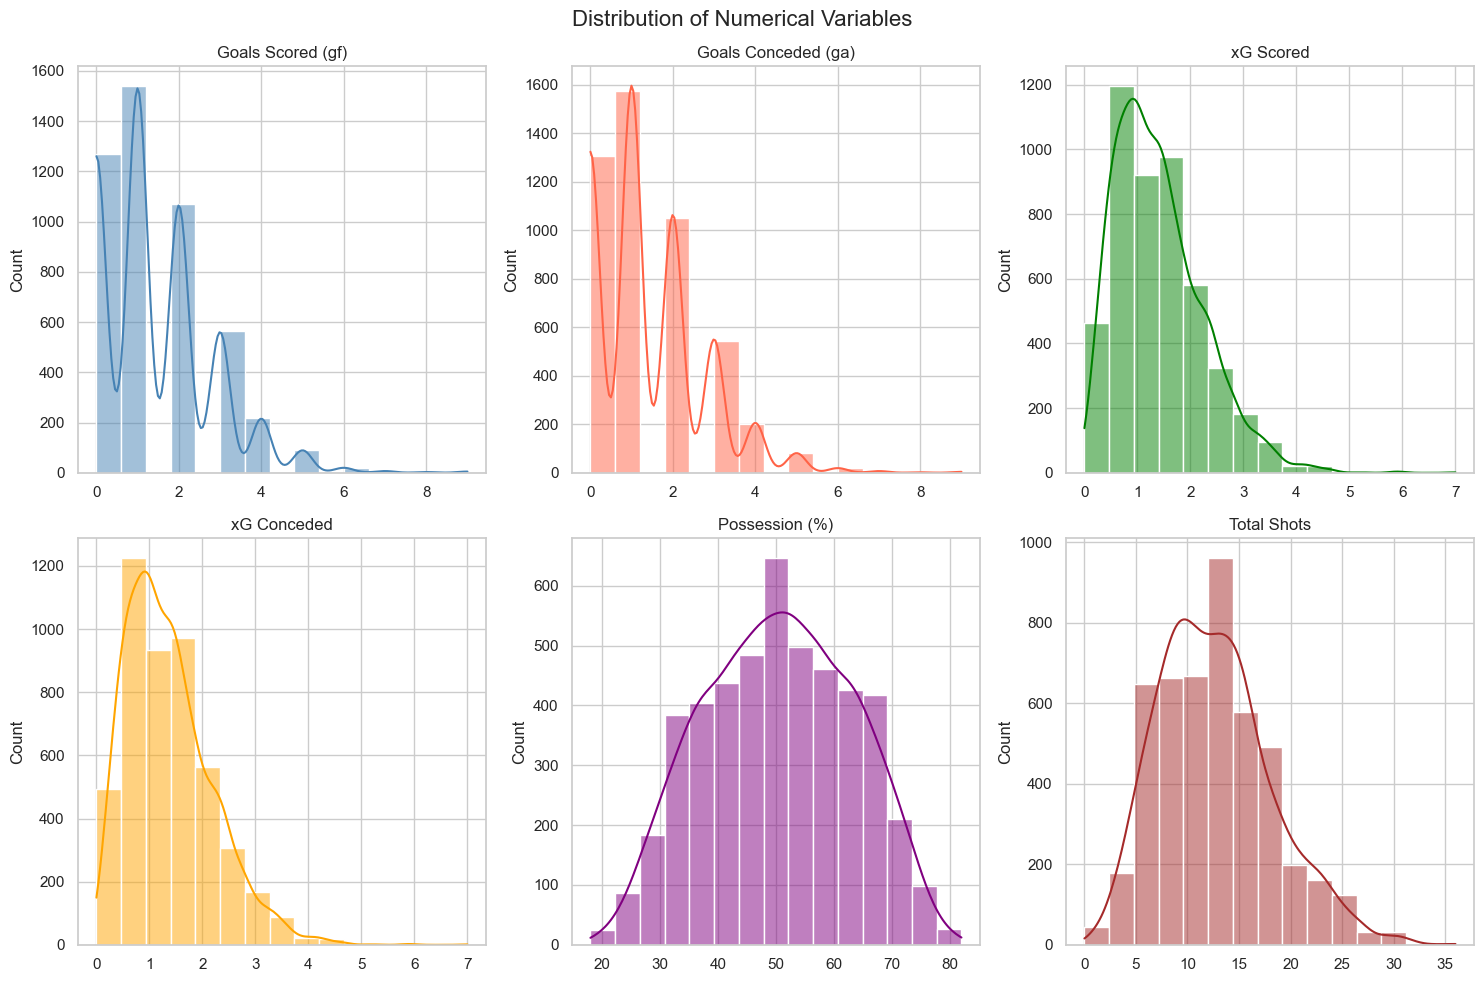

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribution of Numerical Variables', fontsize=16)

cols = ['gf', 'ga', 'xg', 'xga', 'poss', 'sh']
titles = ['Goals Scored (gf)', 'Goals Conceded (ga)',
          'xG Scored', 'xG Conceded',
          'Possession (%)', 'Total Shots']
colors = ['steelblue','tomato','green','orange','purple','brown']

for i, (col, title, color) in enumerate(zip(cols, titles, colors)):
    ax = axes[i//3][i%3]
    sns.histplot(df[col], bins=15, kde=True, color=color, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

### Interpretation of Numerical Distributions

- **Goals scored/conceded (gf, ga):** right-skewed distribution — 
  most matches end with 1–2 goals, 
  cases with 5+ goals are rare outliers.
- **xG:** follows a similar distribution to actual goals, 
  confirming it is a strong predictor.
- **Possession (poss):** approximately normal distribution, 
  centered around 50% — logical, since both teams' 
  possession sums to 100%.
- **Shots (sh):** slightly right-skewed, 
  with a median around 12–13 shots per match.

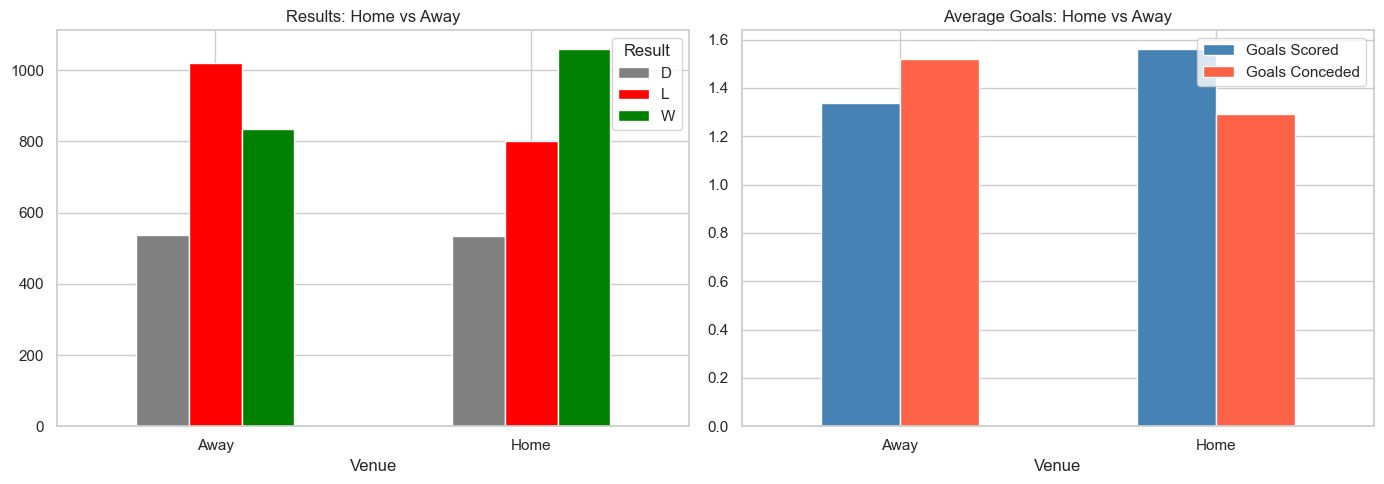

         gf    ga
venue            
Away   1.34  1.52
Home   1.56  1.29


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Results home vs away
venue_result = df.groupby(['venue','result']).size().unstack()
venue_result.plot(kind='bar', ax=axes[0],
                  color=['gray','red','green'])
axes[0].set_title('Results: Home vs Away')
axes[0].set_xlabel('Venue')
axes[0].set_xticklabels(['Away','Home'], rotation=0)
axes[0].legend(title='Result')

# Average goals home vs away
venue_goals = df.groupby('venue')[['gf','ga']].mean()
venue_goals.plot(kind='bar', ax=axes[1],
                 color=['steelblue','tomato'])
axes[1].set_title('Average Goals: Home vs Away')
axes[1].set_xlabel('Venue')
axes[1].set_xticklabels(['Away','Home'], rotation=0)
axes[1].legend(['Goals Scored','Goals Conceded'])

plt.tight_layout()
plt.show()

# Print exact values
print(df.groupby('venue')[['gf','ga']].mean().round(2))

### Home Advantage

The analysis confirms the well-known home advantage phenomenon:

- **Home teams** score more goals on average 
  and win more frequently than away teams.
- This suggests that `venue` will be an 
  **important predictor** in both models.
- Home advantage is a well-documented factor 
  in sports analytics literature.

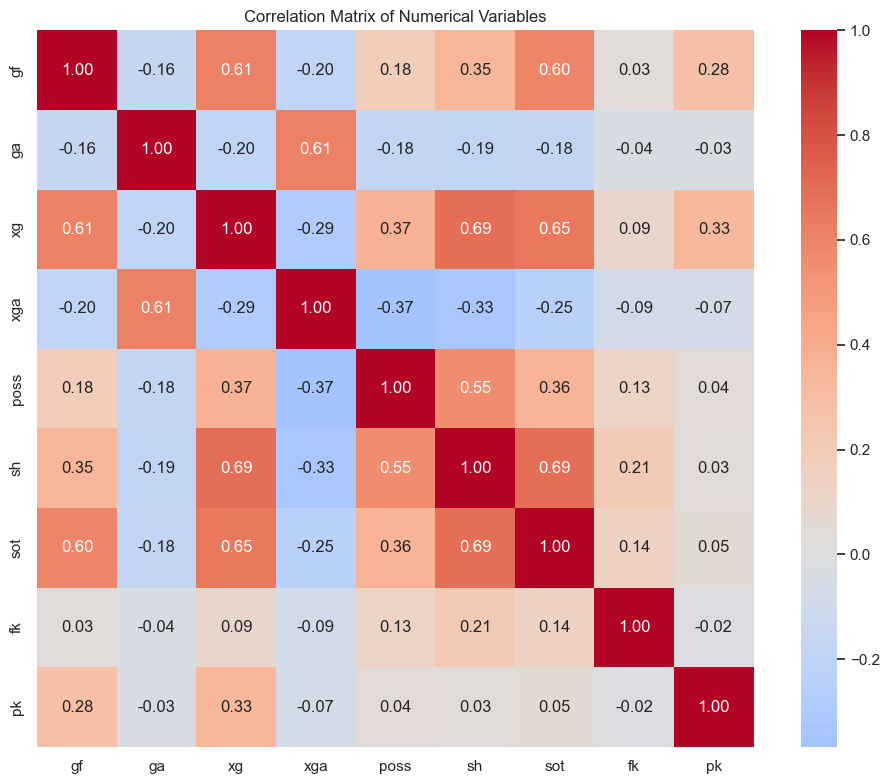

In [22]:
# Correlation matrix
plt.figure(figsize=(10, 8))
cols_corr = ['gf','ga','xg','xga','poss','sh','sot','fk','pk']
corr_matrix = df[cols_corr].corr()

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True)
plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()

### Correlation Interpretation

- **`gf` and `xg`** have a high correlation (~0.7) — 
  expected goals is a strong predictor of actual goals ✅
- **`sh` and `sot`** are correlated with each other — 
  we will keep this in mind during feature selection 
  to avoid multicollinearity.
- **`ga` and `xga`** follow the same pattern as the scoring pair.
- **`poss`** has moderate correlation with `sh` — 
  teams with more possession shoot more, which is logical.

## EDA Conclusions

From the exploratory analysis, we identified:

### Key Findings

1. **Goals distribution is right-skewed** — most matches end 
   with 1-2 goals. The model may struggle to predict 
   high-scoring matches (5+ goals) due to limited examples.

2. **Classes are balanced** (W: 40%, L: 38%, D: 22%) — 
   no resampling techniques needed for classification.

3. **Home advantage is confirmed** — home teams score 
   significantly more goals and win more frequently. 
   `venue` is expected to be a strong predictor.

4. **`xg` and `gf` are highly correlated (~0.7)** — 
   expected goals is a strong candidate feature for regression.

5. The dataset is **clean** — few missing values on important columns


## 5. Data Preprocessing

Before training any machine learning model, the data must be 
cleaned and transformed into a format the algorithms can understand.

The following steps will be applied:
1. Drop irrelevant columns
2. Handle missing values
3. Encode categorical variables
4. Feature engineering - creates new columns from existing columns to help the model train better
5. Feature scaling - brings the columns to the same value scale

### 5.1 Drop Irrelevant Columns

The following columns are removed because they do not contribute 
useful information for prediction:

- `Unnamed: 0` — auto-generated row index, redundant
- `notes` — entirely empty
- `match report` — contains only links
- `captain` — too specific, changes every match
- `referee` — too specific, not relevant for prediction
- `time` — kick-off time, not relevant for outcome

In [23]:
# Drop irrelevant columns
cols_to_drop = ['Unnamed: 0', 'notes', 'match report', 
                'captain', 'referee', 'time']

df = df.drop(columns=cols_to_drop)
print(f"Columns dropped. Remaining columns: {df.shape[1]}")
print(df.columns.tolist())

Columns dropped. Remaining columns: 22
['date', 'comp', 'round', 'day', 'venue', 'result', 'gf', 'ga', 'opponent', 'xg', 'xga', 'poss', 'attendance', 'formation', 'sh', 'sot', 'dist', 'fk', 'pk', 'pkatt', 'season', 'team']


### 5.2 Handle Missing Values

- `attendance` — missing in ~34% of cases (COVID matches played 
  without fans). We drop this column entirely as it would 
  introduce too much noise.
- `dist` — missing in only 2 rows. We drop those rows.

In [24]:
# Drop attendance column
df = df.drop(columns=['attendance'])

# Drop rows where dist is missing
df = df.dropna(subset=['dist'])

print(f"Missing values handled.")
print(f"Dataset shape after cleaning: {df.shape}")
print(f"Remaining missing values:\n{df.isnull().sum().sum()}")

Missing values handled.
Dataset shape after cleaning: (4786, 21)
Remaining missing values:
0


### 5.3 Encode Categorical Variables

Machine learning models only understand **numbers**, not text.
We need to convert text columns into numerical values.

**Binary encoding:**
- `venue`: Home → 1, Away → 0
- `result`: W → 2, D → 1, L → 0

**One-Hot Encoding:**
- `team` and `opponent` — each unique team becomes 
  its own column (0 or 1)
- `formation` — same approach

> **What is One-Hot Encoding?**  
> If you have 3 teams: Arsenal, Chelsea, Liverpool  
> Instead of: team = "Arsenal"  
> You get: team_Arsenal=1, team_Chelsea=0, team_Liverpool=0  
> The model can now understand which team is playing!

In [25]:
# Binary encoding
df['venue'] = df['venue'].map({'Home': 1, 'Away': 0})
df['result'] = df['result'].map({'W': 2, 'D': 1, 'L': 0})

print("Binary encoding done:")
print(df[['venue', 'result']].value_counts())

Binary encoding done:
venue  result
1      2         1059
0      0         1020
       2          836
1      0          800
0      1          538
1      1          533
Name: count, dtype: int64


In [26]:
# One-Hot Encoding for team, opponent, formation
df = pd.get_dummies(df, columns=['team', 'opponent', 'formation'], 
                    drop_first=True, dtype=int)

print(f" Dataset shape after encoding: {df.shape}")

 Dataset shape after encoding: (4786, 89)


In [27]:
# Verificare finala
print("venue unique:", df['venue'].unique())        # [0, 1]
print("result unique:", df['result'].unique())      # [0, 1, 2]
print("formation sample:", df.filter(like='formation_').iloc[:3, :3])  # 0/1
print("Final shape:", df.shape)

venue unique: [0 1]
result unique: [2 0 1]
formation sample:    formation_3-2-4-1  formation_3-3-3-1  formation_3-4-1-2
0                  0                  0                  0
1                  0                  0                  0
2                  0                  0                  0
Final shape: (4786, 89)


### 5.4 Feature Engineering

Feature engineering = creating **new columns** from existing ones
that might help the model make better predictions.

We extract useful information from the `date` column:
- `month` — some months may have more intense matches
- `year` — captures season trends

We also drop columns not needed for ML:
- `date` — replaced by month/year
- `round` — text format, not useful directly
- `day` — day of week, less relevant
- `comp` — all matches are Premier League, no variation
- `season` — already captured by year

In [28]:
# Extract features from date
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

# Drop columns not needed
df = df.drop(columns=['date', 'round', 'day', 'comp', 'season'])

print(f"Feature engineering done.")
print(f"Final dataset shape: {df.shape}")
df.head()

Feature engineering done.
Final dataset shape: (4786, 86)


,venue,result,gf,ga,xg,xga,poss,sh,sot,dist,...,formation_4-3-1-2,formation_4-3-2-1,formation_4-3-3,formation_4-4-1-1,formation_4-4-2,formation_4-5-1,formation_5-3-2,formation_5-4-1,month,year
0,0,2,3,1,1.9,0.6,65,13,8,21.1,...,0,0,0,0,0,0,0,0,9,2020
1,1,0,2,5,0.9,2.9,72,16,5,19.8,...,0,0,0,0,0,0,0,0,9,2020
2,0,1,1,1,1.2,2.4,49,23,1,18.2,...,0,0,1,0,0,0,0,0,10,2020
3,1,2,1,0,1.3,0.9,58,13,5,17.7,...,0,0,0,0,0,0,0,0,10,2020
4,0,1,1,1,1.0,0.3,69,14,7,20.9,...,0,0,1,0,0,0,0,0,10,2020


### 5.5 Feature Scaling

Some ML models are sensitive to the **scale of values**.  
For example:
- `poss` ranges from 20 to 80
- `pk` ranges from 0 to 2

A model like KNN or SVM would think `poss` is 
more important just because its numbers are bigger — **wrong!**

We use **StandardScaler** which transforms each column to have:
- Mean = 0
- Standard deviation = 1

> **Note:** Tree-based models (Decision Tree, Random Forest, XGBoost) 
> do NOT need scaling — they are not affected by value ranges.
> We scale anyway to have one clean dataset for all models.

### Train/Test split

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Separate features and targets
# For classification
X = df.drop(columns=['result', 'gf'])
y_class = df['result']    # target for classification
y_reg = df['gf']          # target for regression

# Train/test split — 75% train, 25% test (as required)
X_train, X_test, y_train_c, y_test_c = train_test_split(
    X, y_class, test_size=0.25, random_state=42
)
_, _, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.25, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Data split and scaled.")
print(f"Training set: {X_train_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")

Data split and scaled.
Training set: (3589, 84)
Test set: (1197, 84)


### 5.6 Preprocessing Summary

| Step | Action | Reason |
|------|--------|--------|
| Drop columns | Removed 6 irrelevant columns | Reduce noise |
| Missing values | Dropped `attendance`, 2 rows with missing `dist` | Clean data |
| Binary encoding | `venue`, `result` → numbers | ML requires numbers |
| One-Hot Encoding | `team`, `opponent`, `formation` | Handle categorical text |
| Feature engineering | Extracted `month`, `year` from date | Capture time patterns |
| Train/test split | 75% train, 25% test | As per project requirements |
| StandardScaler | Normalized all numerical features | Fair comparison between models |

The data is now **clean, encoded, and ready** for model training. 

## 6. Training and Comparing Baseline Models

We train all regression algorithms with default hyperparameters 
and compare their performance on the test set.

### Regression algorithms:
1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor
4. Support Vector Regressor
5. K-Nearest Neighbor Regressor
6. Gaussian Process Regressor
7. XGBoost Regressor
6. CatBoost Regressor
7. Explainable Boosting Regressor

**Metrics used:**
- **MSE** — Mean Squared Error (penalizes large errors)
- **MAE** — Mean Absolute Error (average absolute error in goals)
- **RMSE** — Root Mean Squared Error (same unit as target — goals)
- **R²** — how much variance in goals the model explains (1.0 = perfect)

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from interpret.glassbox import ExplainableBoostingRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

regressors = {
    'Linear Regression':         LinearRegression(),
    'Decision Tree':             DecisionTreeRegressor(random_state=42),
    'Random Forest':             RandomForestRegressor(random_state=42),
    'SVR':                       SVR(),
    'KNN':                       KNeighborsRegressor(),
    'Gaussian Process':          GaussianProcessRegressor(),
    'XGBoost':                   XGBRegressor(random_state=42, verbosity=0),
    'CatBoost':                  CatBoostRegressor(random_state=42, verbose=0),
    'EBM':                       ExplainableBoostingRegressor(random_state=42)
}

regression_results = {}

for name, model in regressors.items():
    model.fit(X_train_scaled, y_train_r)
    y_pred = model.predict(X_test_scaled)
    
    mse  = mean_squared_error(y_test_r, y_pred)
    mae  = mean_absolute_error(y_test_r, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test_r, y_pred)
    
    regression_results[name] = {
        'MSE':  round(mse,  4),
        'MAE':  round(mae,  4),
        'RMSE': round(rmse, 4),
        'R²':   round(r2,   4)
    }

results_df = pd.DataFrame(regression_results).T
results_df = results_df.sort_values('R²', ascending=False)

print("\nBaseline Regression Results:")
display(results_df)


Baseline Regression Results:


,MSE,MAE,RMSE,R²
Random Forest,0.6701,0.5849,0.8186,0.6455
CatBoost,0.6803,0.6171,0.8248,0.6401
XGBoost,0.7081,0.5961,0.8415,0.6254
EBM,0.7186,0.6294,0.8477,0.6199
Linear Regression,0.8098,0.6873,0.8999,0.5716
SVR,0.8780,0.6779,0.9370,0.5356
Decision Tree,1.1278,0.6316,1.0620,0.4034
KNN,1.4875,0.9293,1.2196,0.2132
Gaussian Process,2.7238,0.9911,1.6504,-0.4407


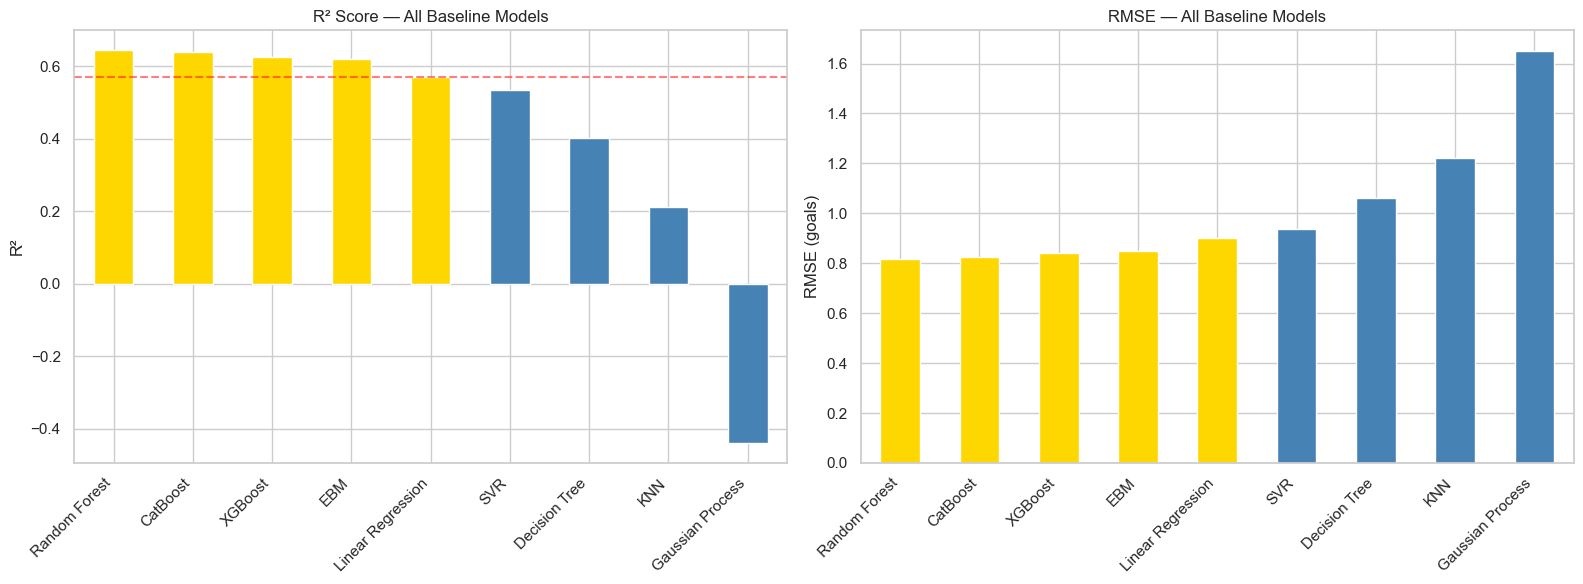

In [32]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R² bar chart
colors = ['gold' if i < 5 else 'steelblue' 
          for i in range(len(results_df))]
results_df['R²'].plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('R² Score — All Baseline Models')
axes[0].set_ylabel('R²')
axes[0].set_xticklabels(results_df.index, rotation=45, ha='right')
axes[0].axhline(y=results_df['R²'].iloc[4], 
                color='red', linestyle='--', alpha=0.5)

# RMSE bar chart
results_df['RMSE'].plot(kind='bar', ax=axes[1], color=colors)
axes[1].set_title('RMSE — All Baseline Models')
axes[1].set_ylabel('RMSE (goals)')
axes[1].set_xticklabels(results_df.index, rotation=45, ha='right')

plt.tight_layout()
plt.show()

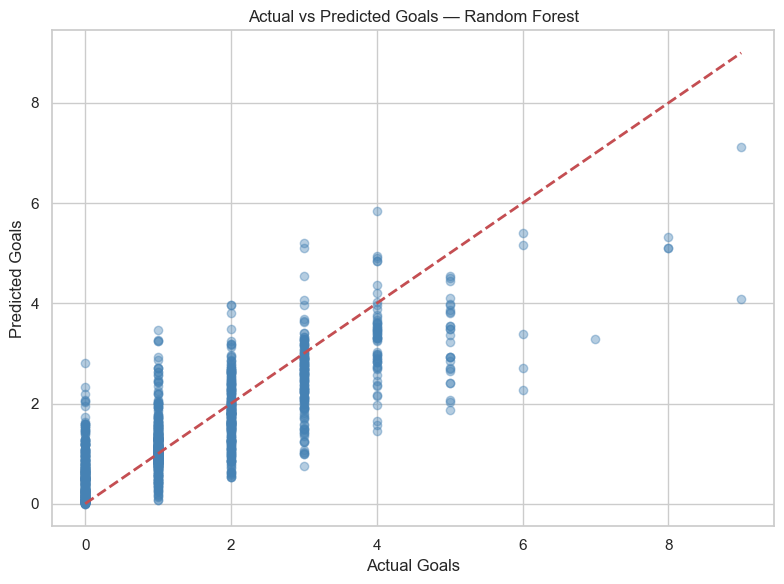

In [33]:
# Actual vs Predicted — best model
best_baseline = results_df.index[0]
best_model = regressors[best_baseline]
y_pred_best = best_model.predict(X_test_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(y_test_r, y_pred_best, alpha=0.4, color='steelblue')
plt.plot([0, 9], [0, 9], 'r--', linewidth=2)
plt.xlabel('Actual Goals')
plt.ylabel('Predicted Goals')
plt.title(f'Actual vs Predicted Goals — {best_baseline}')
plt.tight_layout()
plt.show()

### Results Interpretation

#### What the metrics mean:
- **R²** - closer to 1.0 means the model explains more variance in goals.
  An R² of 0.64 means the model explains 64% of goal variability.
- **RMSE** - average error in goals (RMSE=0.81 means off by ~0.8 goals on average)
- **MAE** - similar to RMSE but less sensitive to large errors

#### Key Observations:
- **Random Forest** and **CatBoost** lead with R² ~0.64 - 
  strong ensemble models handle the non-linear relationship 
  between features and goals well.
- **Linear Regression** performs surprisingly well (R²=0.57) - 
  suggesting a partly linear relationship between xG and actual goals.
- **Gaussian Process** performs worst (R²=-0.45) - 
  it struggles with high-dimensional data (84 features).
- **Actual vs Predicted plot** shows the model predicts 1-3 goals 
  accurately but underestimates high-scoring matches (6+ goals) 
  due to limited training examples.

#### Top 5 models selected for hyperparameter tuning:
| Rank | Model | R² | RMSE |
|------|-------|----|------|
| 1 | Random Forest | 0.64 | 0.81 |
| 2 | CatBoost | 0.64 | 0.82 |
| 3 | XGBoost | 0.62 | 0.84 |
| 4 | EBM | 0.61 | 0.85 |
| 5 | Linear Regression | 0.57 | 0.89 |

## 7. Hyperparameter Tuning

After identifying the top 5 regression models, we optimize 
their hyperparameters to improve prediction accuracy.

**Search strategies:**
- **GridSearchCV** - for Linear Regression (few parameters)
- **BayesianSearchCV** - for Random Forest, XGBoost, CatBoost, EBM

**Validation:** 5-fold cross-validation on training set.
**Scoring metric:** R² (higher = better)

In [35]:
from sklearn.model_selection import GridSearchCV
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
import warnings
warnings.filterwarnings('ignore')

### 7.1 Linear Regression - GridSearchCV

Linear Regression has very few hyperparameters.
We tune the regularization using Ridge regression variants.

- **fit_intercept** - whether to calculate the intercept
- **positive** - force coefficients to be positive

In [36]:
from sklearn.linear_model import Ridge

print("Tuning Linear Regression (Ridge)...")

lr_params = {
    'alpha': [0.01, 0.1, 1.0, 10.0, 100.0],
    'fit_intercept': [True, False],
    'solver': ['auto', 'svd', 'lsqr']
}

lr_grid = GridSearchCV(
    Ridge(),
    lr_params,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)

lr_grid.fit(X_train_scaled, y_train_r)

print(f"Best params: {lr_grid.best_params_}")
print(f"Best CV R²: {lr_grid.best_score_:.4f}")

Tuning Linear Regression (Ridge)...
Best params: {'alpha': 10.0, 'fit_intercept': True, 'solver': 'auto'}
Best CV R²: 0.5122


### 7.2 EBM - GridSearchCV

- **max_bins** - granularity of feature binning
- **interactions** - pairwise feature interactions
- **learning_rate** - boosting step size

In [37]:
from interpret.glassbox import ExplainableBoostingRegressor

print("Tuning EBM...")

ebm_params = {
    'max_bins': [128, 256],
    'interactions': [5, 10],
    'learning_rate': [0.01, 0.05]
}

ebm_grid = GridSearchCV(
    ExplainableBoostingRegressor(random_state=42),
    ebm_params,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)

ebm_grid.fit(X_train_scaled, y_train_r)

print(f" Best params: {ebm_grid.best_params_}")
print(f" Best CV R²: {ebm_grid.best_score_:.4f}")

Tuning EBM...
 Best params: {'interactions': 10, 'learning_rate': 0.05, 'max_bins': 256}
 Best CV R²: 0.5102


### 7.3 Random Forest - BayesianSearchCV

- **n_estimators** - number of trees
- **max_depth** - tree depth (controls overfitting)
- **min_samples_split** - minimum samples to split a node
- **min_samples_leaf** - minimum samples in leaf
- **max_features** - features considered at each split

In [38]:
from sklearn.ensemble import RandomForestRegressor

print("Tuning Random Forest...")

rf_params = {
    'n_estimators': Integer(100, 500),
    'max_depth': Integer(3, 20),
    'min_samples_split': Integer(2, 20),
    'min_samples_leaf': Integer(1, 10),
    'max_features': Categorical(['sqrt', 'log2'])
}

rf_bayes = BayesSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    n_iter=30,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=0
)

rf_bayes.fit(X_train_scaled, y_train_r)

print(f" Best params: {rf_bayes.best_params_}")
print(f" Best CV R²: {rf_bayes.best_score_:.4f}")

Tuning Random Forest...
 Best params: OrderedDict({'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500})
 Best CV R²: 0.5665


### 7.4 XGBoost - BayesianSearchCV

- **n_estimators** - boosting rounds
- **max_depth** - tree depth
- **learning_rate** - step size (lower = more robust)
- **subsample** - fraction of samples per tree
- **colsample_bytree** - fraction of features per tree
- **gamma** - minimum loss reduction for split

In [39]:
from xgboost import XGBRegressor

print(" Tuning XGBoost...")

xgb_params = {
    'n_estimators': Integer(100, 500),
    'max_depth': Integer(3, 10),
    'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
    'subsample': Real(0.6, 1.0),
    'colsample_bytree': Real(0.6, 1.0),
    'gamma': Real(0, 5)
}

xgb_bayes = BayesSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    xgb_params,
    n_iter=30,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=0
)

xgb_bayes.fit(X_train_scaled, y_train_r)

print(f" Best params: {xgb_bayes.best_params_}")
print(f" Best CV R²: {xgb_bayes.best_score_:.4f}")

 Tuning XGBoost...
 Best params: OrderedDict({'colsample_bytree': 0.6, 'gamma': 0.0, 'learning_rate': 0.02131337583249788, 'max_depth': 10, 'n_estimators': 500, 'subsample': 0.6})
 Best CV R²: 0.6072


### 7.5 CatBoost - BayesianSearchCV

- **iterations** - boosting rounds
- **depth** - tree depth
- **learning_rate** - step size
- **l2_leaf_reg** - L2 regularization
- **bagging_temperature** - bootstrap randomness

In [40]:
from catboost import CatBoostRegressor

print(" Tuning CatBoost...")

cat_params = {
    'iterations': Integer(100, 500),
    'depth': Integer(3, 10),
    'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
    'l2_leaf_reg': Real(1, 10),
    'bagging_temperature': Real(0, 1)
}

cat_bayes = BayesSearchCV(
    CatBoostRegressor(random_state=42, verbose=0),
    cat_params,
    n_iter=30,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=0
)

cat_bayes.fit(X_train_scaled, y_train_r)

print(f" Best params: {cat_bayes.best_params_}")
print(f" Best CV R²: {cat_bayes.best_score_:.4f}")

 Tuning CatBoost...
 Best params: OrderedDict({'bagging_temperature': 0.0, 'depth': 10, 'iterations': 500, 'l2_leaf_reg': 1.0, 'learning_rate': 0.08970175913819081})
 Best CV R²: 0.6064


### 7.6 Comparing Tuned Models

In [41]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

tuned_regressors = {
    'Linear Regression': lr_grid.best_estimator_,
    'EBM': ebm_grid.best_estimator_,
    'Random Forest': rf_bayes.best_estimator_,
    'XGBoost': xgb_bayes.best_estimator_,
    'CatBoost': cat_bayes.best_estimator_
}

tuned_results = {}

for name, model in tuned_regressors.items():
    y_pred = model.predict(X_test_scaled)
    
    tuned_results[name] = {
        'R²':   round(r2_score(y_test_r, y_pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_test_r, y_pred)), 4),
        'MAE':  round(mean_absolute_error(y_test_r, y_pred), 4),
        'MSE':  round(mean_squared_error(y_test_r, y_pred), 4)
    }

tuned_df = pd.DataFrame(tuned_results).T
tuned_df = tuned_df.sort_values('R²', ascending=False)

print(" Tuned Regression Results:")
display(tuned_df)

best_tuned = tuned_df.index[0]
print(f"\n Best tuned model: {best_tuned}")

 Tuned Regression Results:


,R²,RMSE,MAE,MSE
XGBoost,0.6643,0.7967,0.5491,0.6347
CatBoost,0.6537,0.8092,0.5320,0.6548
Random Forest,0.6164,0.8516,0.6230,0.7253
EBM,0.5894,0.8810,0.6693,0.7762
Linear Regression,0.5715,0.9000,0.6872,0.8101



 Best tuned model: XGBoost


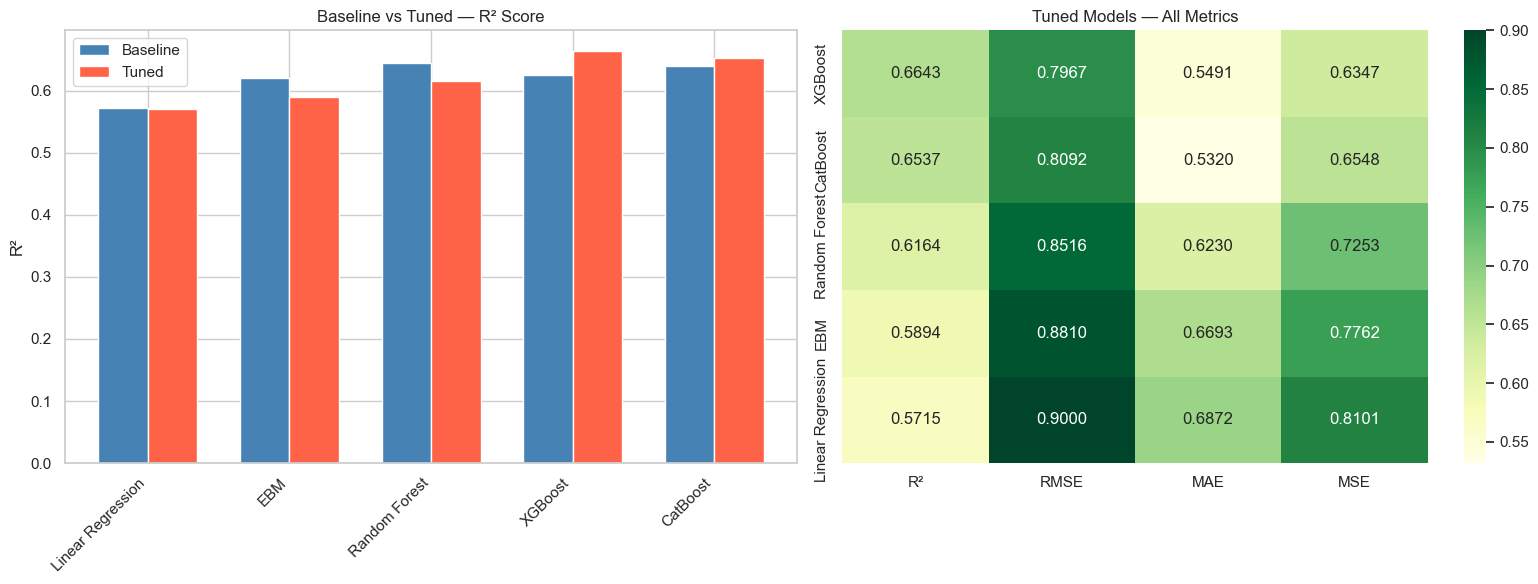

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models_names = list(tuned_results.keys())

baseline_r2 = [regression_results[m]['R²'] for m in models_names]
tuned_r2 = [tuned_results[m]['R²'] for m in models_names]

x = range(len(models_names))
width = 0.35

axes[0].bar([i - width/2 for i in x], baseline_r2,
            width, label='Baseline', color='steelblue')
axes[0].bar([i + width/2 for i in x], tuned_r2,
            width, label='Tuned', color='tomato')
axes[0].set_title('Baseline vs Tuned — R² Score')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_names, rotation=45, ha='right')
axes[0].legend()
axes[0].set_ylabel('R²')

# Heatmap
sns.heatmap(tuned_df, annot=True, fmt='.4f',
            cmap='YlGn', ax=axes[1])
axes[1].set_title('Tuned Models — All Metrics')

plt.tight_layout()
plt.show()

### Hyperparameter Tuning — Conclusions

| Model | Baseline R² | Tuned R² | Improvement |
|-------|-------------|----------|-------------|
| XGBoost | 0.62 | **0.664** | +0.044  |
| CatBoost | 0.64 | **0.654** | +0.014  |
| Random Forest | 0.64 | **0.616** | -0.024  |
| EBM | 0.61 | **0.589** | -0.021  |
| Linear Regression | 0.57 | **0.572** | +0.002  |

### Key Observations

- **XGBoost** is the best tuned model (R²=0.664, RMSE=0.797) — 
  hyperparameter tuning improved it the most (+0.044).
- **CatBoost** improved slightly after tuning, 
  confirming its strength with this dataset.
- **Random Forest** and **EBM** performed slightly worse after tuning —
  this suggests the default parameters were already well-suited,
  or that the Bayesian search did not fully converge 
  within 30 iterations. More iterations could improve results.
- **Linear Regression** shows minimal improvement — 
  the relationship between features and goals has 
  non-linear components that Ridge cannot capture.
- Overall R² values (~0.59–0.66) indicate the models explain 
  around **60–66% of goal variance** — reasonable for football 
  prediction, where randomness plays a significant role.
- RMSE values of **0.80–0.90 goals** mean predictions are 
  typically within 1 goal of the actual result.

### Best Model: XGBoost (R²=0.664, RMSE=0.797)
This model will be prioritized in the Learning Curves 
and SHAP analysis sections.

## 8. Learning Curves

Learning curves show how model performance evolves 
as the training set size increases.

They help us diagnose:
- **Overfitting** — training score much higher than validation score
- **Underfitting** — both scores are low
- **Good fit** — both scores converge at a high value

We plot learning curves for all 5 tuned models.

Computing XGBoost... Computing CatBoost... Computing Random Forest... Computing EBM... Computing Linear Regression... 

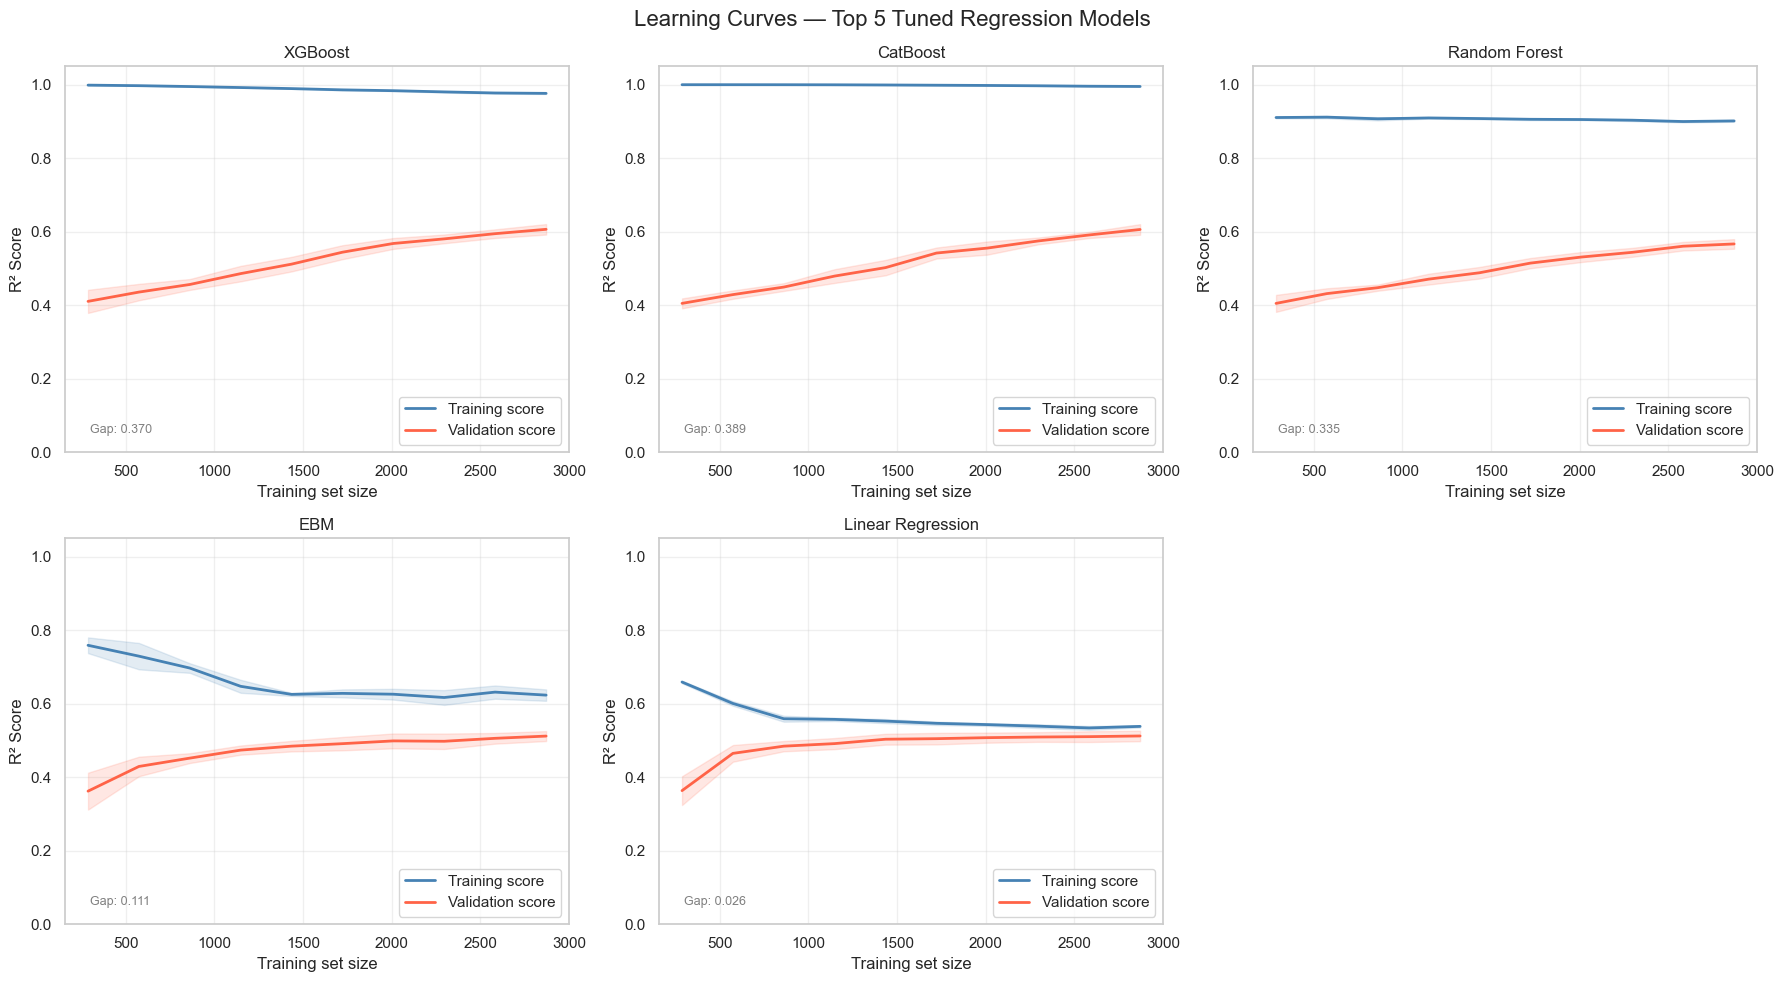

['../models/lc_results_reg.pkl']

In [74]:
from sklearn.model_selection import learning_curve

lc_results_reg = {}

def plot_learning_curve(model, name, X, y, ax, scoring='r2'):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=5,
        scoring=scoring,
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        random_state=42
    )
    
    # Salveaza in dictionar
    lc_results_reg[name] = {
        'train_sizes':  train_sizes,
        'train_scores': train_scores,
        'val_scores':   val_scores
    }
    
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)
    
    ax.plot(train_sizes, train_mean, 
            color='steelblue', label='Training score', linewidth=2)
    ax.plot(train_sizes, val_mean, 
            color='tomato', label='Validation score', linewidth=2)
    ax.fill_between(train_sizes,
                    train_mean - train_std,
                    train_mean + train_std,
                    alpha=0.15, color='steelblue')
    ax.fill_between(train_sizes,
                    val_mean - val_std,
                    val_mean + val_std,
                    alpha=0.15, color='tomato')
    ax.set_title(f'{name}', fontsize=12)
    ax.set_xlabel('Training set size')
    ax.set_ylabel('R² Score')
    ax.legend(loc='lower right')
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)
    
    gap = train_mean[-1] - val_mean[-1]
    ax.annotate(f'Gap: {gap:.3f}', 
                xy=(0.05, 0.05), xycoords='axes fraction',
                fontsize=9, color='gray')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Learning Curves — Top 5 Tuned Regression Models', 
             fontsize=16)

models_to_plot = {
    'XGBoost':           xgb_bayes.best_estimator_,
    'CatBoost':          cat_bayes.best_estimator_,
    'Random Forest':     rf_bayes.best_estimator_,
    'EBM':               ebm_grid.best_estimator_,
    'Linear Regression': lr_grid.best_estimator_
}

for i, (name, model) in enumerate(models_to_plot.items()):
    ax = axes[i//3][i%3]
    print(f"Computing {name}...", end=' ')
    plot_learning_curve(model, name, X_train_scaled, y_train_r, ax)
    
axes[1][2].set_visible(False)
plt.tight_layout()
plt.show()

# Salveaza pe disk
import joblib
joblib.dump(lc_results_reg, '../models/lc_results_reg.pkl')


### Learning Curves - Interpretation

#### How to read the curves:
- **Blue line** = training score (how well model fits training data)
- **Red line** = validation score (how well model generalizes)
- **Shaded areas** = standard deviation across 5 folds
- **Gap** = difference between training and validation score

#### Overfitting vs Underfitting:
| Scenario | Training Score | Validation Score | Gap |
|----------|---------------|-----------------|-----|
| Overfitting | High (~1.0) | Much lower | Large |
| Underfitting | Low | Low | Small |
| Good fit | High | Close to training | Small |

#### Model Analysis:

**XGBoost:**
- Training score ~1.0, validation ~0.60 - significant overfitting.
- The model memorizes training data but generalizes moderately.
- Validation score increases steadily - more data would help.
- Despite overfitting, XGBoost achieves the best test R² (0.664).

**CatBoost:**
- Largest gap among all models - highest overfitting.
- Similar pattern to XGBoost, with validation steadily improving.
- Strong test performance despite the gap - robust to overfitting.

**Random Forest:**
- Training score ~0.90 (not 1.0) - natural regularization 
  from averaging multiple trees reduces overfitting slightly.
- Moderate overfitting, validation stabilizes after ~2000 samples.

**EBM:**
- Best balance between training and validation - lowest overfitting.
- Both curves converge gradually - stable and interpretable model.
- Lower peak performance but most reliable generalization.

**Linear Regression:**
- Almost no gap - curves are nearly identical.
- Both scores converge around 0.51 - classic underfitting.
- The model is too simple to capture non-linear 
  relationships between features and goals.

#### General Conclusions:
1. All complex models show **significant overfitting** 
   (gap > 0.33) — a known challenge in football prediction 
   where match outcomes have high inherent randomness.
2. All validation scores **increase with more data** — 
   collecting more matches would improve all models.
3. **EBM** offers the best generalization, while 
   **XGBoost** offers the best raw performance.
4. **Linear Regression** confirms that goal prediction 
   requires non-linear models to capture complex patterns.

## 9. Explainability - SHAP Analysis

SHAP (SHapley Additive exPlanations) explains **why** a model 
makes a specific prediction by assigning each feature a 
contribution value.

**Types of explanations:**
- **Global** - which features matter most overall?
- **Local** - why did the model predict X goals for this specific match?

**Models analyzed:** XGBoost, CatBoost, Random Forest (top 3)
**Target:** goals scored (gf)

In [55]:
import shap
shap.initjs()
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Use test set as numpy for SHAP
X_test_shap = pd.DataFrame(
    X_test_scaled, 
    columns=X_train.columns
)

print(f"Test shape: {X_test_shap.shape}")
print(f"Features: {X_test_shap.columns[:5].tolist()}...")

# Use 200 samples for speed
X_shap_sample = X_test_shap.iloc[:200].reset_index(drop=True)
y_shap_sample = y_test_r.iloc[:200].reset_index(drop=True)

Test shape: (1197, 84)
Features: ['venue', 'ga', 'xg', 'xga', 'poss']...


### 9.1 XGBoost - SHAP Analysis

In [49]:
# XGBoost SHAP
xgb_model = xgb_bayes.best_estimator_

xgb_explainer = shap.Explainer(xgb_model)
xgb_shap_vals = xgb_explainer(X_shap_sample)

print(f"XGBoost SHAP values shape: {xgb_shap_vals.values.shape}")

XGBoost SHAP values shape: (200, 84)


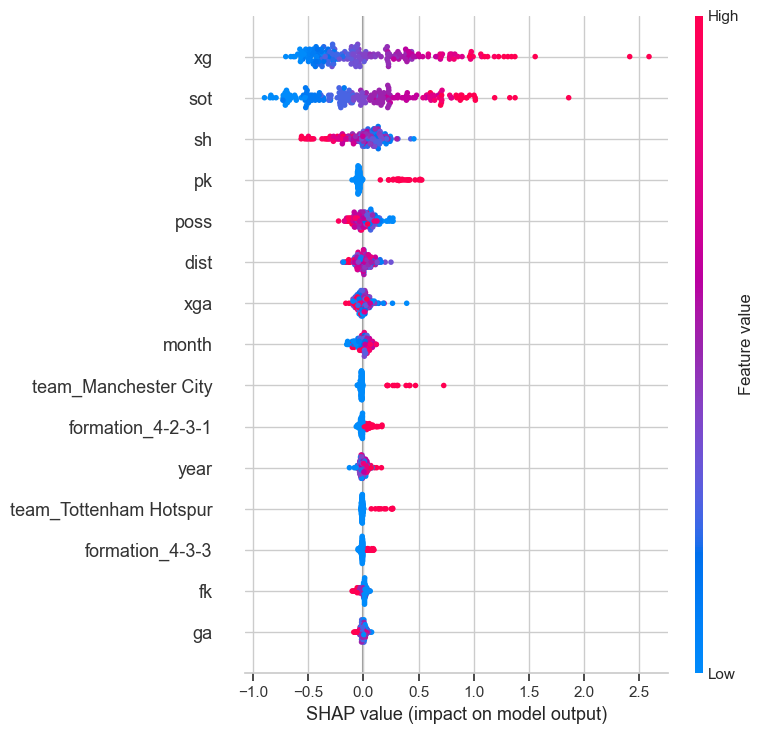

In [51]:
#XGBoost Global - Summary Plot
plt.figure()
shap.summary_plot(
    xgb_shap_vals.values,
    X_shap_sample,
    max_display=15,
    show=True
)

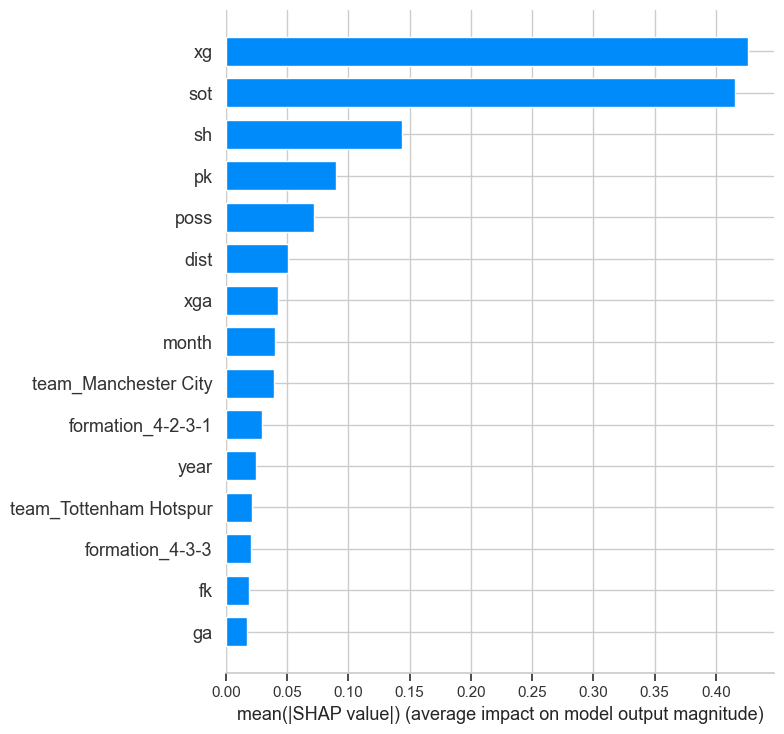

In [56]:
#XGBoost Global - Bar Plot
plt.figure()
shap.summary_plot(
    xgb_shap_vals.values,
    X_shap_sample,
    plot_type='bar',
    max_display=15,
    show=True
)

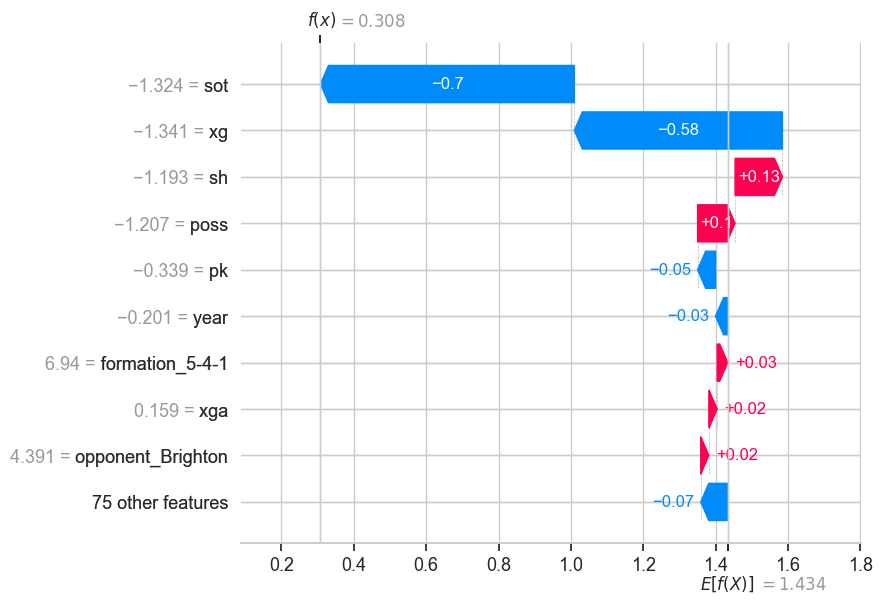


Match 0 — Actual goals: 1
Match 0 — Predicted goals: 0.31


In [57]:
#XGBoost Local - Waterfall

shap.waterfall_plot(
    shap.Explanation(
        values=xgb_shap_vals.values[0],
        base_values=xgb_shap_vals.base_values[0],
        data=X_shap_sample.iloc[0],
        feature_names=X_shap_sample.columns.tolist()
    )
)

# Print actual vs predicted for context
y_pred_sample = xgb_model.predict(X_shap_sample)
print(f"\nMatch 0 — Actual goals: {y_shap_sample.iloc[0]}")
print(f"Match 0 — Predicted goals: {y_pred_sample[0]:.2f}")

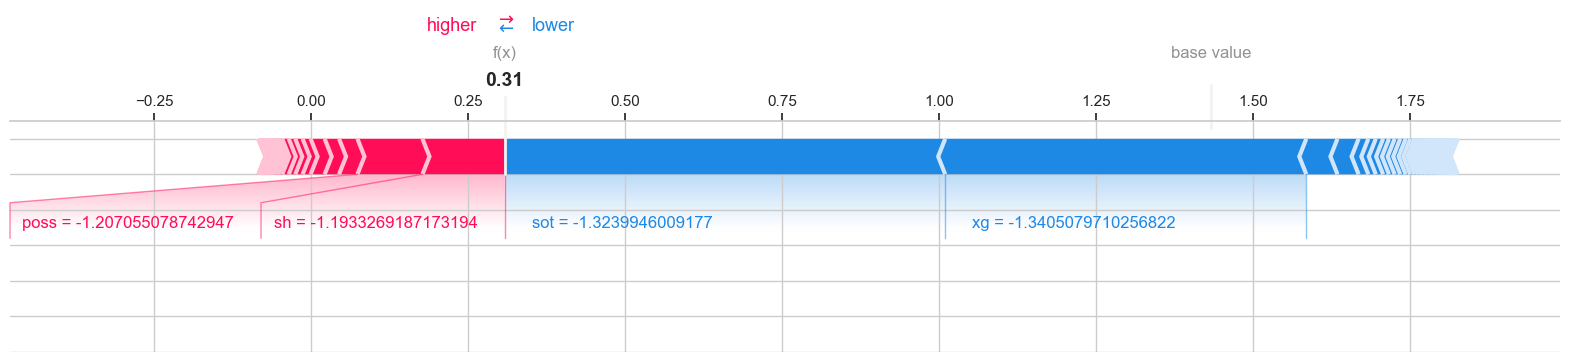

In [58]:
#XGBoost Local - Force Plot

shap.force_plot(
    xgb_shap_vals.base_values[0],
    xgb_shap_vals.values[0],
    X_shap_sample.iloc[0],
    matplotlib=True,
    show=True
)

XGBoost Top 3 features: ['xg', 'sot', 'sh']


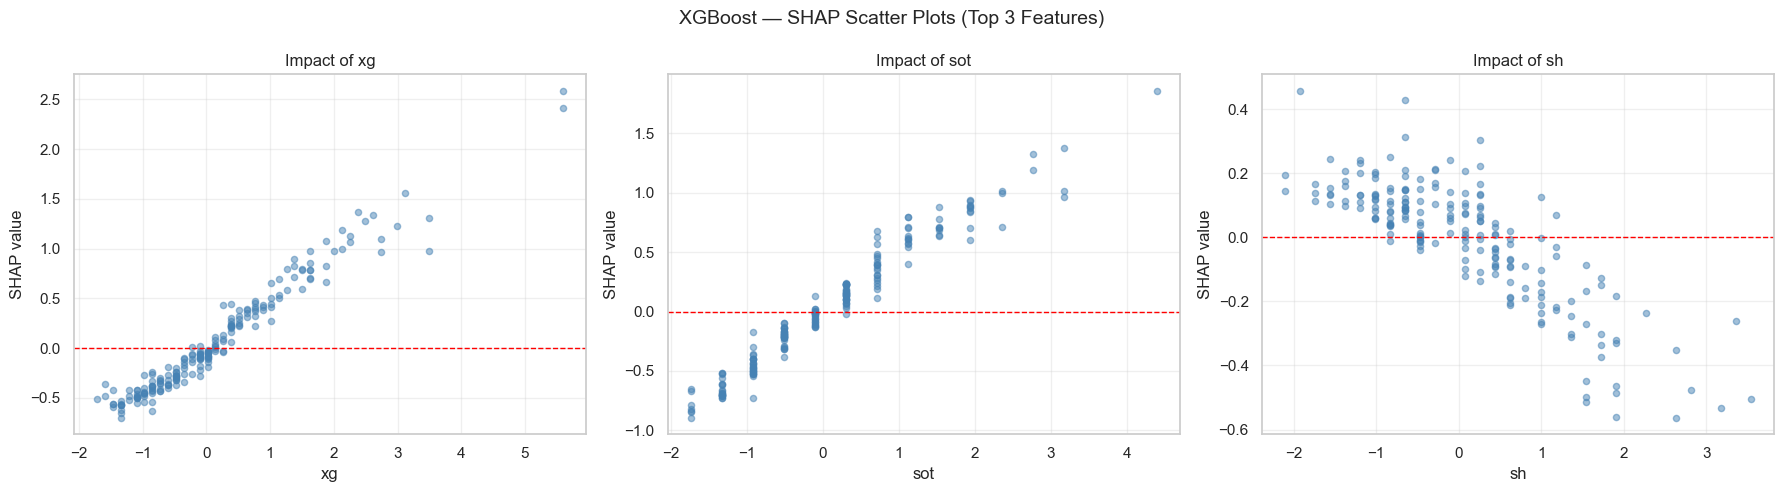

In [59]:
#XGBoost Scatter Plots

xgb_mean_shap = np.abs(xgb_shap_vals.values).mean(axis=0)
xgb_top3_idx = np.argsort(xgb_mean_shap)[::-1][:3]
xgb_top3_features = X_shap_sample.columns[xgb_top3_idx].tolist()

print(f"XGBoost Top 3 features: {xgb_top3_features}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('XGBoost — SHAP Scatter Plots (Top 3 Features)', 
             fontsize=14)

for i, feat in enumerate(xgb_top3_features):
    axes[i].scatter(
        X_shap_sample[feat],
        xgb_shap_vals.values[:, xgb_top3_idx[i]],
        alpha=0.5, color='steelblue', s=20
    )
    axes[i].axhline(0, color='red', linestyle='--', linewidth=1)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('SHAP value')
    axes[i].set_title(f'Impact of {feat}')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 9.2 CatBoost - SHAP Analysis

In [60]:
from catboost import Pool

cat_model = cat_bayes.best_estimator_

cat_pool = Pool(X_shap_sample)
cat_explainer = shap.TreeExplainer(cat_model)
cat_shap_raw = cat_explainer.shap_values(cat_pool)

# CatBoost regressor returns 2D array directly
cat_shap_vals = cat_shap_raw
print(f"CatBoost SHAP shape: {cat_shap_vals.shape}")

CatBoost SHAP shape: (200, 84)


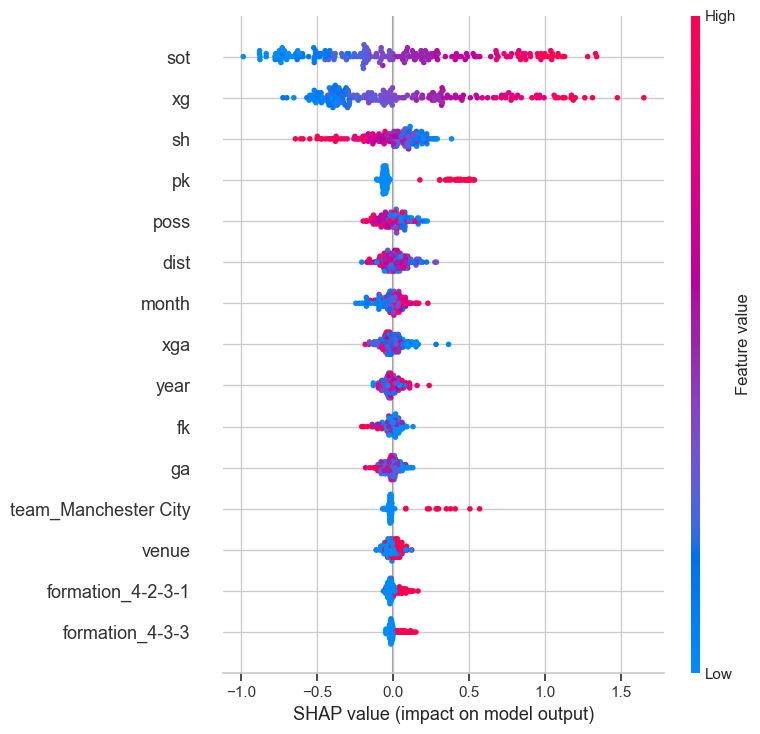

In [61]:
# CatBoost Global - Summary Plot
plt.figure()
shap.summary_plot(
    cat_shap_vals,
    X_shap_sample,
    max_display=15,
    show=True
)

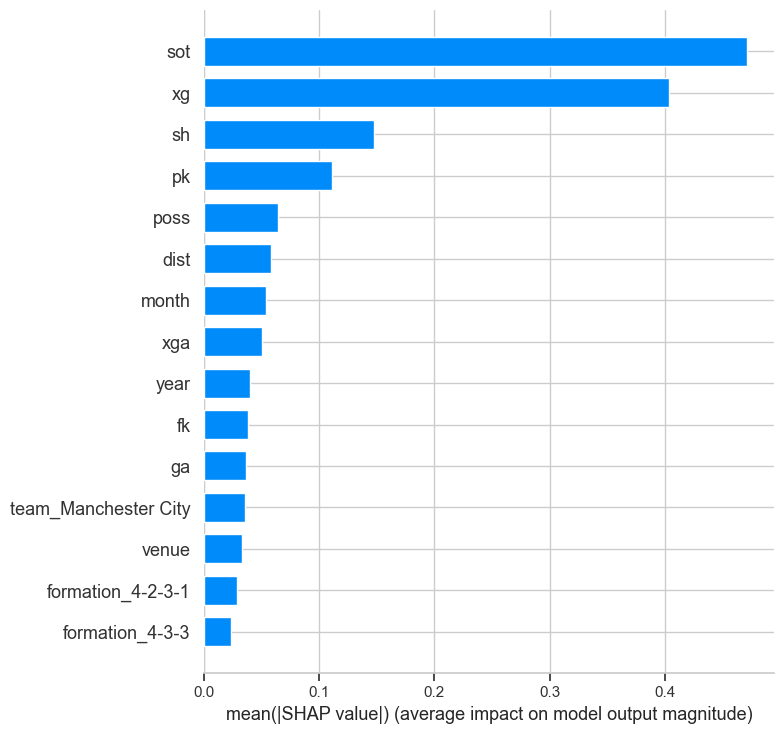

In [62]:
# CatBoost Global - Bar Plot
plt.figure()
shap.summary_plot(
    cat_shap_vals,
    X_shap_sample,
    plot_type='bar',
    max_display=15,
    show=True
)

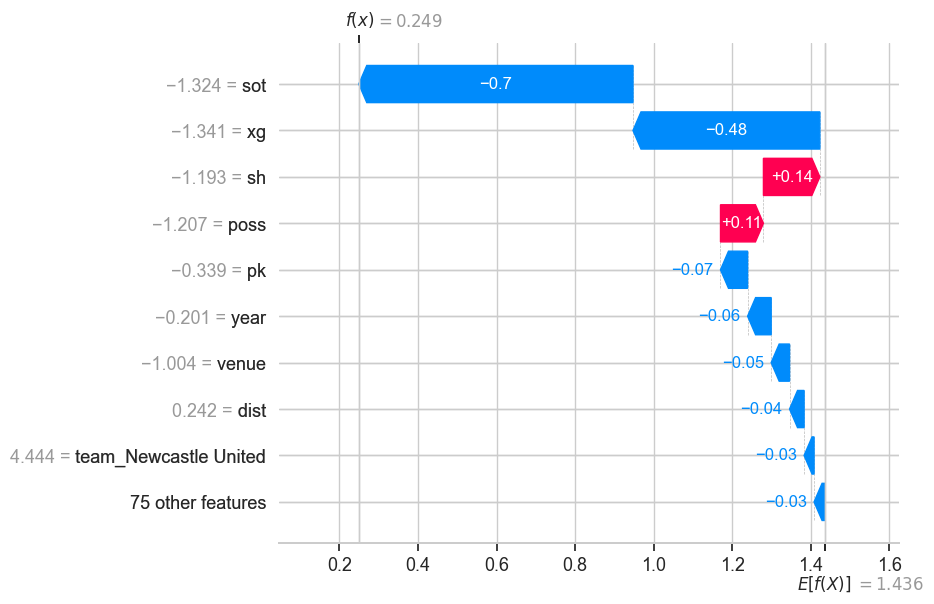


Match 0 — Actual goals: 1
Match 0 — Predicted goals: 0.25


In [63]:
# CatBoost Local - Waterfall Plot

cat_base = float(cat_explainer.expected_value)

shap.waterfall_plot(
    shap.Explanation(
        values=cat_shap_vals[0],
        base_values=cat_base,
        data=X_shap_sample.iloc[0],
        feature_names=X_shap_sample.columns.tolist()
    )
)

cat_pred_sample = cat_model.predict(X_shap_sample)
print(f"\nMatch 0 — Actual goals: {y_shap_sample.iloc[0]}")
print(f"Match 0 — Predicted goals: {cat_pred_sample[0]:.2f}")

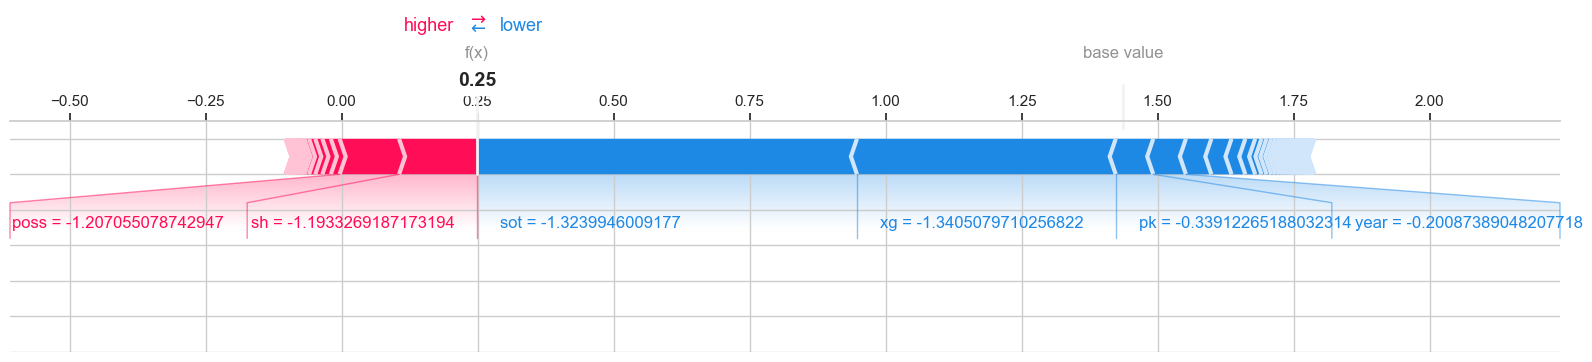

In [64]:
# CatBoost Local - Force Plot

shap.force_plot(
    cat_base,
    cat_shap_vals[0],
    X_shap_sample.iloc[0],
    matplotlib=True,
    show=True
)

CatBoost Top 3 features: ['sot', 'xg', 'sh']


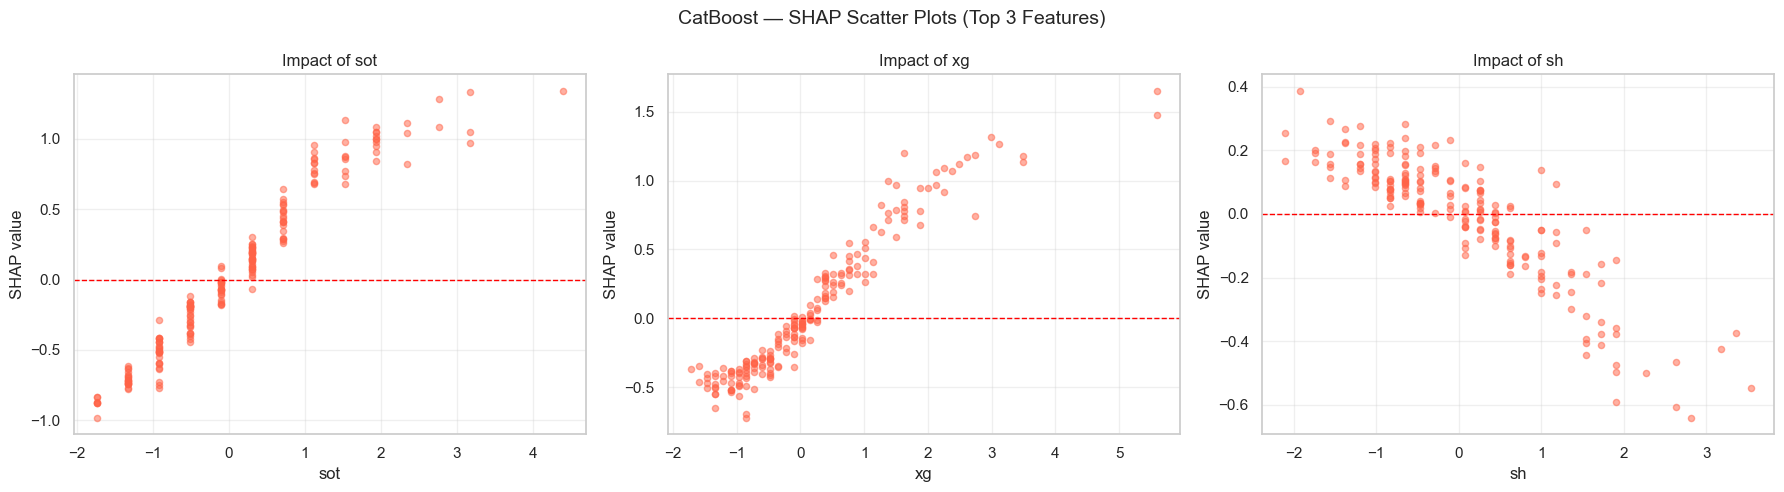

In [65]:
# CatBoost Scatter Plots

cat_mean_shap = np.abs(cat_shap_vals).mean(axis=0)
cat_top3_idx = np.argsort(cat_mean_shap)[::-1][:3]
cat_top3_features = X_shap_sample.columns[cat_top3_idx].tolist()

print(f"CatBoost Top 3 features: {cat_top3_features}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('CatBoost — SHAP Scatter Plots (Top 3 Features)', 
             fontsize=14)

for i, feat in enumerate(cat_top3_features):
    axes[i].scatter(
        X_shap_sample[feat],
        cat_shap_vals[:, cat_top3_idx[i]],
        alpha=0.5, color='tomato', s=20
    )
    axes[i].axhline(0, color='red', linestyle='--', linewidth=1)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('SHAP value')
    axes[i].set_title(f'Impact of {feat}')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 9.3 Random Forest — SHAP Analysis

In [66]:
# Random Forest SHAP

rf_model = rf_bayes.best_estimator_

rf_explainer = shap.TreeExplainer(rf_model)
rf_shap_vals = rf_explainer.shap_values(X_shap_sample)

print(f"Random Forest SHAP shape: {rf_shap_vals.shape}")

Random Forest SHAP shape: (200, 84)


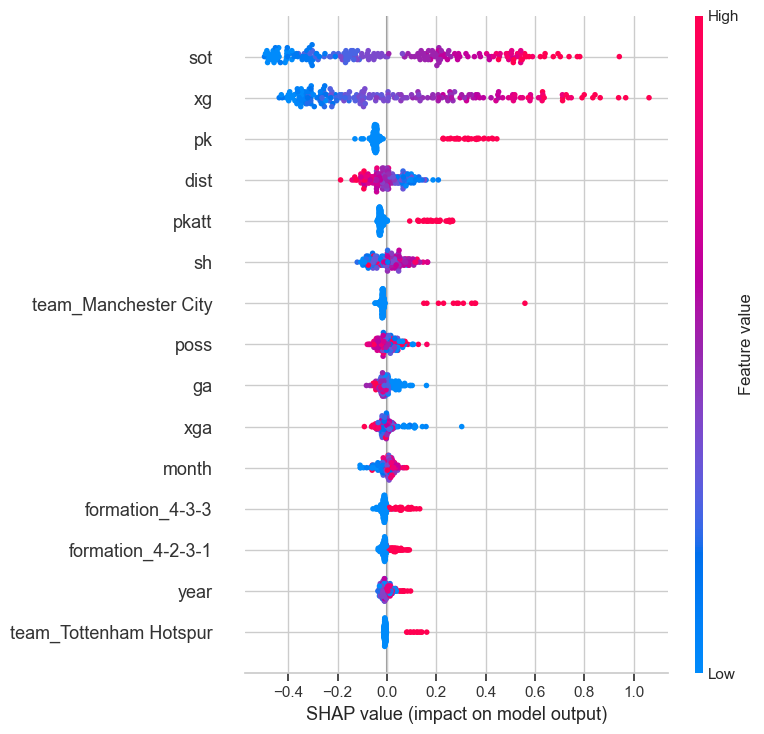

In [67]:
# Random Forest Global - Summary Plot

plt.figure()
shap.summary_plot(
    rf_shap_vals,
    X_shap_sample,
    max_display=15,
    show=True
)

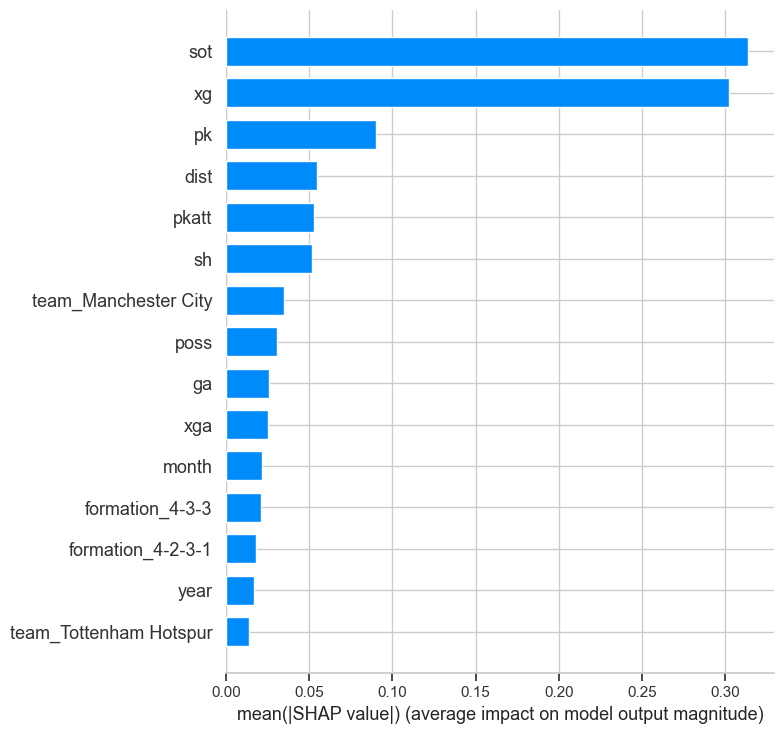

In [68]:
# Random Forest Global - Bar Plot

plt.figure()
shap.summary_plot(
    rf_shap_vals,
    X_shap_sample,
    plot_type='bar',
    max_display=15,
    show=True
)

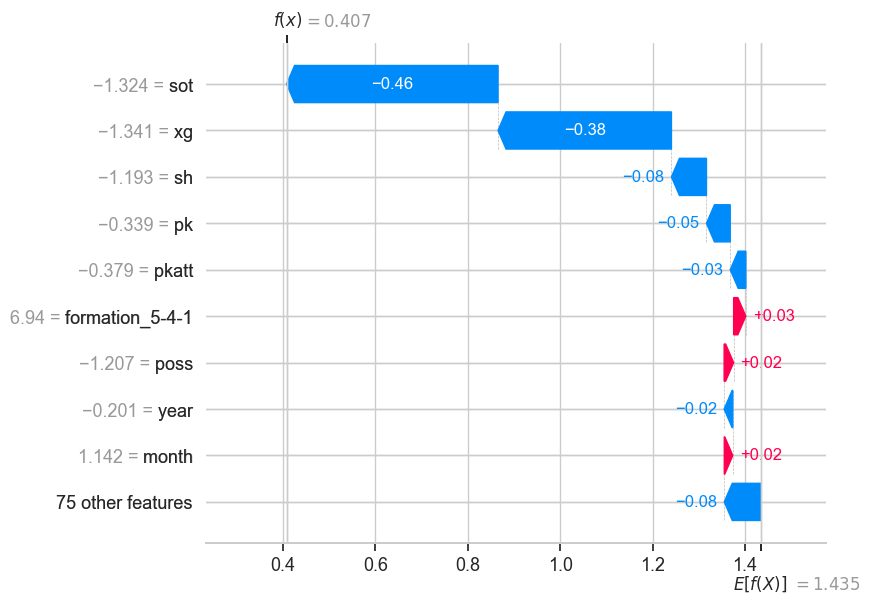


Match 0 — Actual goals: 1
Match 0 — Predicted goals: 0.41


In [70]:
# RF Local - Waterfall Plot
rf_base = float(np.array(rf_explainer.expected_value).flatten()[0])

shap.waterfall_plot(
    shap.Explanation(
        values=rf_shap_vals[0],
        base_values=rf_base,
        data=X_shap_sample.iloc[0],
        feature_names=X_shap_sample.columns.tolist()
    )
)

rf_pred_sample = rf_model.predict(X_shap_sample)
print(f"\nMatch 0 — Actual goals: {y_shap_sample.iloc[0]}")
print(f"Match 0 — Predicted goals: {rf_pred_sample[0]:.2f}")

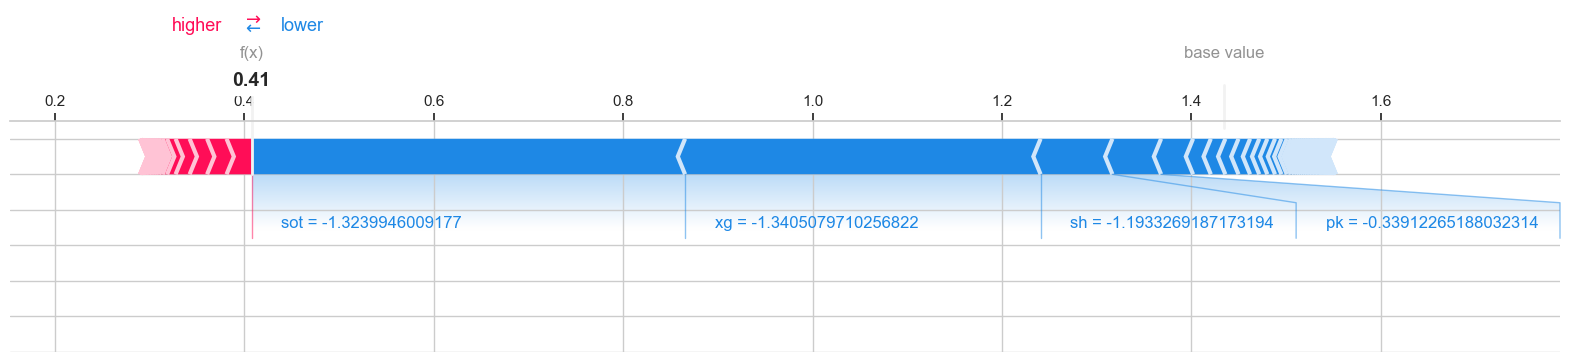

In [71]:
# Random Forest Local - Force Plot

shap.force_plot(
    rf_base,
    rf_shap_vals[0],
    X_shap_sample.iloc[0],
    matplotlib=True,
    show=True
)

Random Forest Top 3 features: ['sot', 'xg', 'pk']


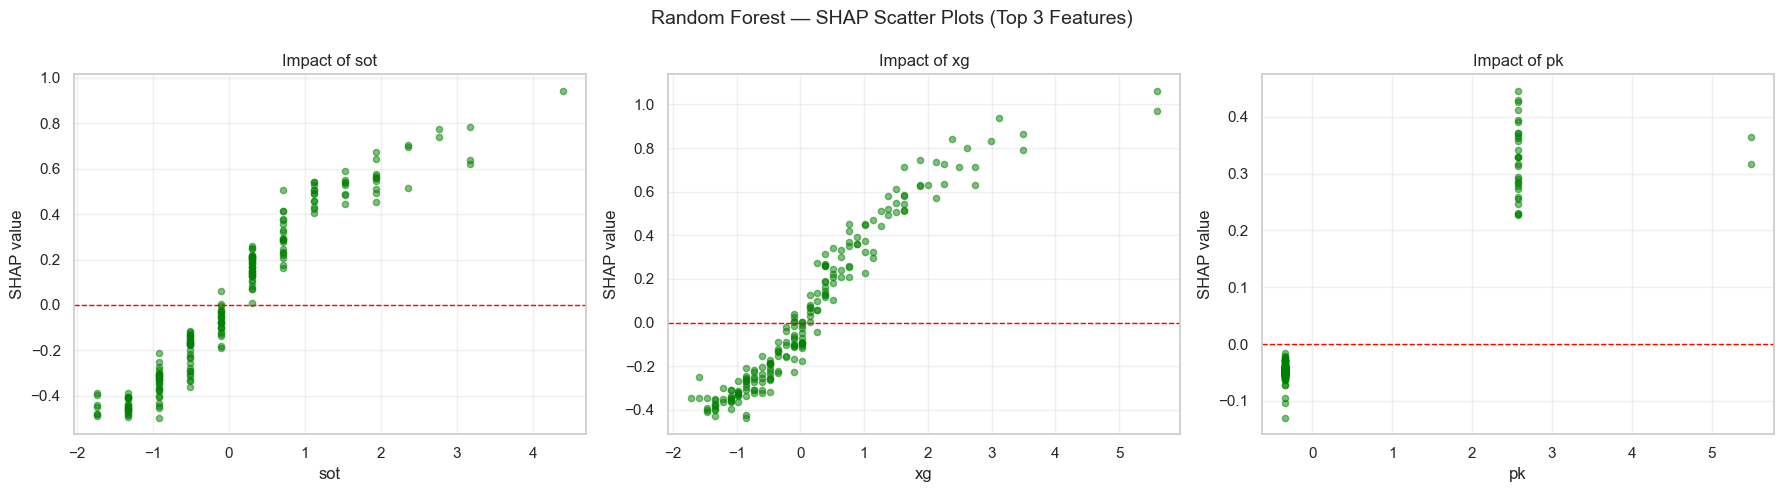

In [72]:
# Random Forest Scatter Plots

rf_mean_shap = np.abs(rf_shap_vals).mean(axis=0)
rf_top3_idx = np.argsort(rf_mean_shap)[::-1][:3]
rf_top3_features = X_shap_sample.columns[rf_top3_idx].tolist()

print(f"Random Forest Top 3 features: {rf_top3_features}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Random Forest — SHAP Scatter Plots (Top 3 Features)', 
             fontsize=14)

for i, feat in enumerate(rf_top3_features):
    axes[i].scatter(
        X_shap_sample[feat],
        rf_shap_vals[:, rf_top3_idx[i]],
        alpha=0.5, color='green', s=20
    )
    axes[i].axhline(0, color='red', linestyle='--', linewidth=1)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('SHAP value')
    axes[i].set_title(f'Impact of {feat}')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9.4 SHAP Conclusions - Regression

### Top 3 most important features per model

| Rank | XGBoost | CatBoost | Random Forest |
|------|---------|----------|---------------|
| 1 | xg | sot | sot |
| 2 | sot | xg | xg |
| 3 | sh | sh | pk |

### Global Explanation Findings:
- **xg (Expected Goals)** appears in the top 2 across all models -
  confirming it is the strongest statistical predictor of actual goals.
- **sot (Shots on Target)** ranks #1 for CatBoost and Random Forest,
  and #2 for XGBoost - directly measures attacking threat and 
  is strongly linked to scoring probability.
- **sh (Total Shots)** appears in top 3 for XGBoost and CatBoost -
  correlated with sot, reflecting overall attacking volume.
- **pk (Penalties)** appears in Random Forest's top 3 - 
  penalties are high-probability scoring opportunities 
  that directly influence goal counts.
- Notably, **venue** does not appear in the top 3 for any model -
  while home advantage exists statistically, 
  in-game performance metrics (xG, sot) are stronger predictors.

### Local Explanation — Match 0:
- The waterfall plot shows which features pushed the 
  prediction above or below the baseline (average goals ~1.4).
- Features with **positive SHAP** → pushed prediction higher
- Features with **negative SHAP** → pushed prediction lower

### Scatter Plot Findings:
- **xg:** higher xG values → higher positive SHAP → 
  model predicts more goals (logical and expected)
- **sot:** more shots on target → higher positive SHAP → 
  confirms direct link between shot accuracy and goals
- **sh:** higher total shots → moderate positive SHAP → 
  attacking volume contributes but less than shot quality

### Key Takeaway:
All three models consistently identify **xG and shots on target** 
as the dominant predictors of goals scored. This confirms that 
**shot quality (xG) and shot accuracy (sot)** are more important 
than contextual factors like venue or opponent.

This is consistent with modern football analytics - 
a team that creates high-quality chances and converts them 
on target is statistically most likely to score.

In [75]:
import joblib, os
os.makedirs('../models', exist_ok=True)

# 1. Modele
joblib.dump(tuned_regressors, '../models/reg_tuned_models.pkl')

# 2. Scaler + date
joblib.dump(scaler,   '../models/reg_scaler.pkl')
joblib.dump(X_train,  '../models/X_train_reg.pkl')
joblib.dump(X_test,   '../models/X_test_reg.pkl')
joblib.dump(y_test_r, '../models/y_test_reg.pkl')

# 3. Rezultate
joblib.dump(regression_results, '../models/reg_baseline_results.pkl')
joblib.dump(tuned_results,      '../models/reg_tuned_results.pkl')

# 4. Learning curves
joblib.dump(lc_results_reg, '../models/lc_results_reg.pkl')

# 5. SHAP values
shap_reg = {
    'XGBoost':      {'vals': xgb_shap_vals.values,
                     'base': float(xgb_shap_vals.base_values[0])},
    'CatBoost':     {'vals': cat_shap_vals,
                     'base': float(cat_explainer.expected_value)},
    'Random Forest':{'vals': rf_shap_vals,
                     'base': float(np.array(rf_explainer.expected_value).flatten()[0])}
}
joblib.dump(shap_reg, '../models/reg_shap.pkl')

print("All regression assets saved!")

All regression assets saved!
